In [459]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('fivethirtyeight')
import warnings
warnings.filterwarnings('ignore')
# Показывать графики прямо внутри ноутбука под ячейкой кода.
%matplotlib inline

# Part 1

# 1. Первичный анализ данных


In [460]:
data = pd.read_csv('train.csv')

In [461]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [462]:
data.isnull().sum() # где сколько пропусков

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### Пропуски:
- Cabin - 687
- Age - 177
- Embarked - 2

## Эвристика обработки пропусков (раскроется более подробно далее):
### 1) Возраст заполним средними значениями групп, в зависимости от приставки, которая идёт перед именем (Mr, Miss, Master итд.)
### 2) Порт посадки - всего 2 пропуска, можем предположить, что скорее всего это люди с порта, где село на борт наибольшее количество людей - Southampton и заполнить значения им.

## Общий график сколько всего выжило

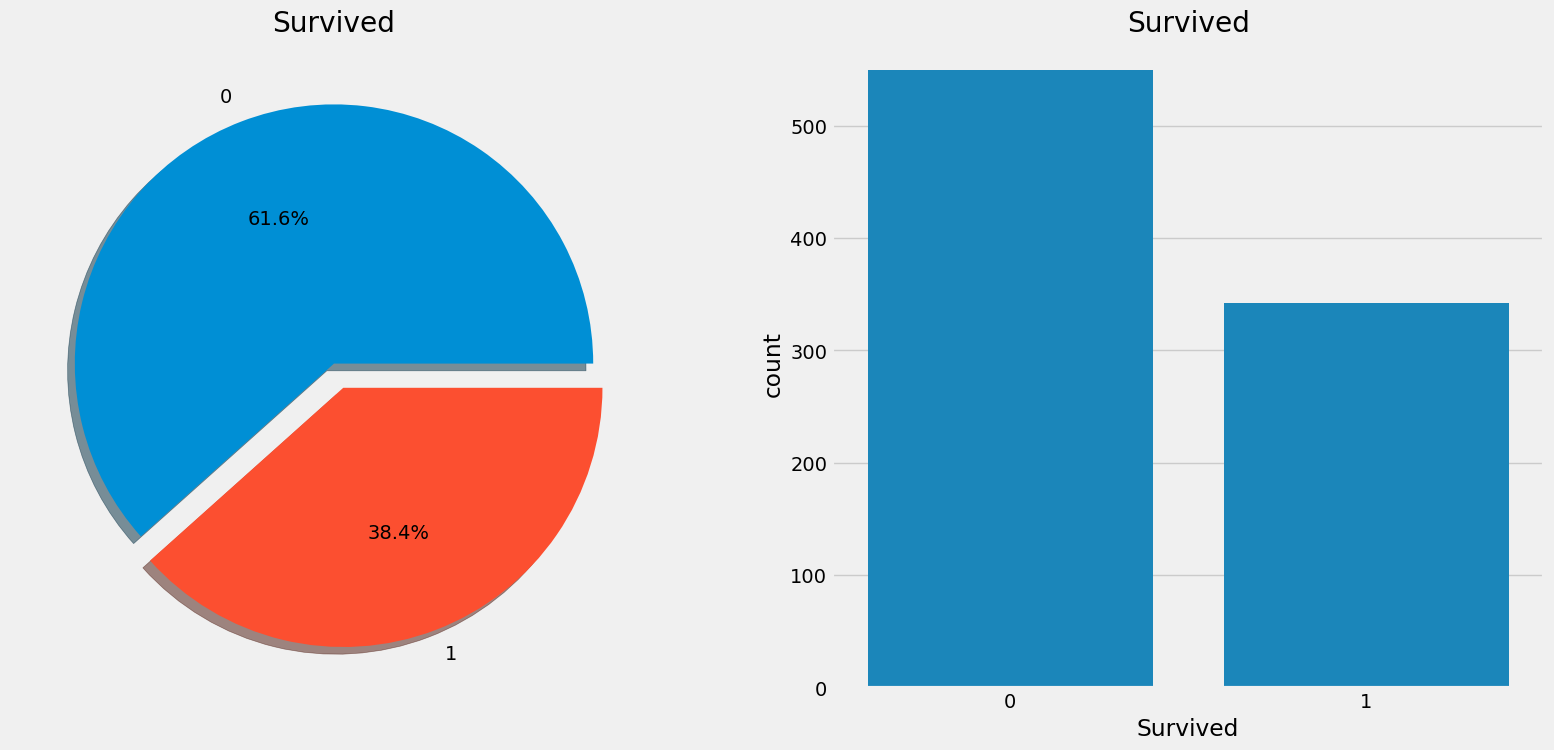

In [463]:
fig, ax = plt.subplots(1, 2, figsize=(18, 8))

data['Survived'].value_counts().plot.pie(
    # Немного «вытаскивает» один сектор из круга. 0.1 — второй сектор отодвигается от центра на небольшое расстояние.
    explode=[0, 0.1],
    # Добавляет на круговую диаграмму проценты.
    autopct='%1.1f%%',
    ax=ax[0],
    shadow=True
)

ax[0].set_title('Survived')
ax[0].set_ylabel('')

# sns.countplot(data=таблица, x='название_столбца')
sns.countplot(data=data, x='Survived', ax=ax[1])
ax[1].set_title('Survived')

plt.show()

# 2. Analysing The Features¶

## 2.1 Sex is strong feature.

## Вывод информации сколько выжило в зависимости от пола и какая часть внутри пола выжила.

In [464]:
data.groupby(['Sex','Survived'])['Survived'].count()

Sex     Survived
female  0            81
        1           233
male    0           468
        1           109
Name: Survived, dtype: int64

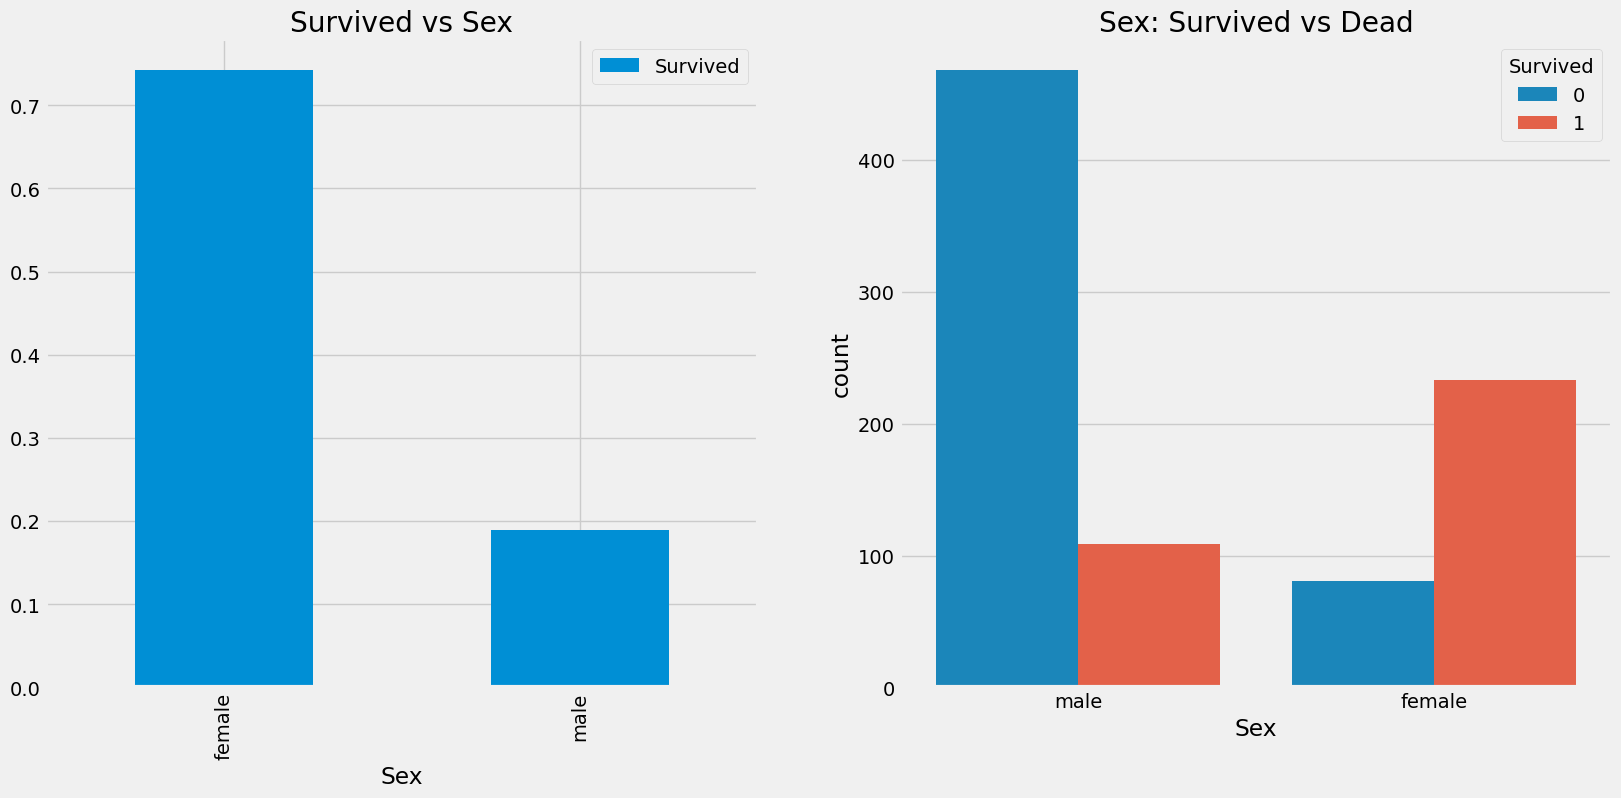

In [465]:
f,ax=plt.subplots(1,2,figsize=(18,8))
data[['Sex','Survived']].groupby(['Sex']).mean().plot.bar(ax=ax[0])
ax[0].set_title('Survived vs Sex')
# hue в Seaborn — это параметр, который делит данные внутри одной категории на подгруппы и показывает их разными цветами.
sns.countplot(data=data, x= "Sex", hue='Survived',ax=ax[1])
ax[1].set_title('Sex: Survived vs Dead')
plt.show()

## 2.2 Ordinary feature PClass.

### We can clearly see that Passenegers Of Pclass 1 were given a very high priority while rescue

### Вывод кол-ва выживших в зависимости от класса, также вывод какая часть была выживших внутри конкретного класса.

In [466]:
pd.crosstab(data.Pclass, data.Survived, margins=True).style.background_gradient(cmap='summer_r')

Survived,0,1,All
Pclass,,,
1,80,136,216
2,97,87,184
3,372,119,491
All,549,342,891


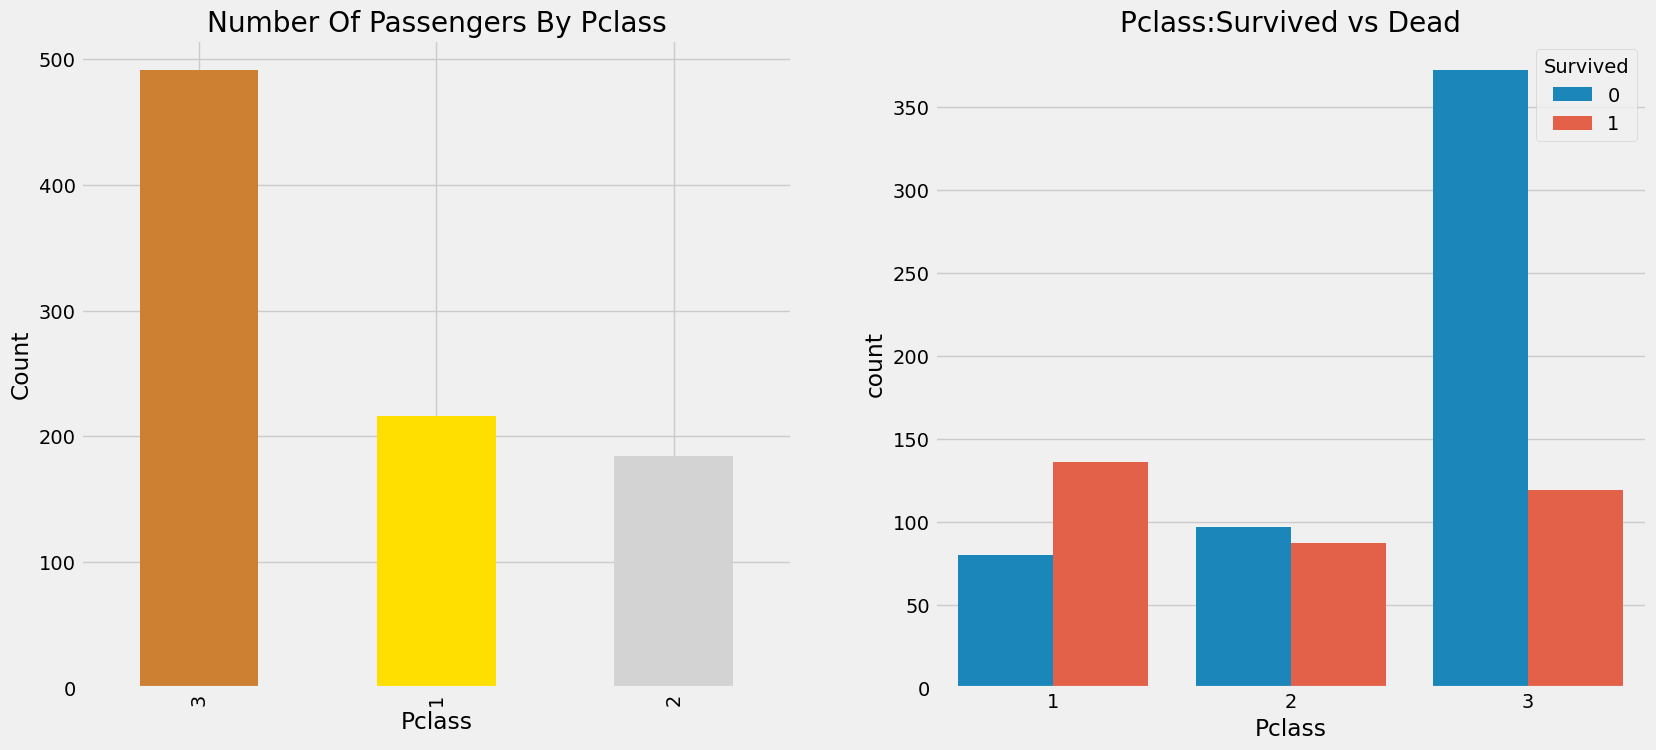

In [467]:
f,ax=plt.subplots(1,2,figsize=(18,8))
data['Pclass'].value_counts().plot.bar(color=['#CD7F32','#FFDF00','#D3D3D3'],ax=ax[0])
ax[0].set_title('Number Of Passengers By Pclass')
ax[0].set_ylabel('Count')
sns.countplot(data=data, x='Pclass', hue='Survived',ax=ax[1])
ax[1].set_title('Pclass:Survived vs Dead')
plt.show()

> ### По общему количеству выжило больше людей из 3 класса, но их и было намного больше и процент выжиших внутри класса самый маленький. Самый большой процент выживших внутри класса у 1 класса.

## 2.3 Checking survival rate with Sex and Pclass Together.

### It is evident that irrespective of Pclass, Women were given first priority while rescue. Even Men from Pclass1 have a very low survival rate.

In [468]:
pd.crosstab([data.Sex,data.Survived],data.Pclass,margins=True).style.background_gradient(cmap='summer_r')

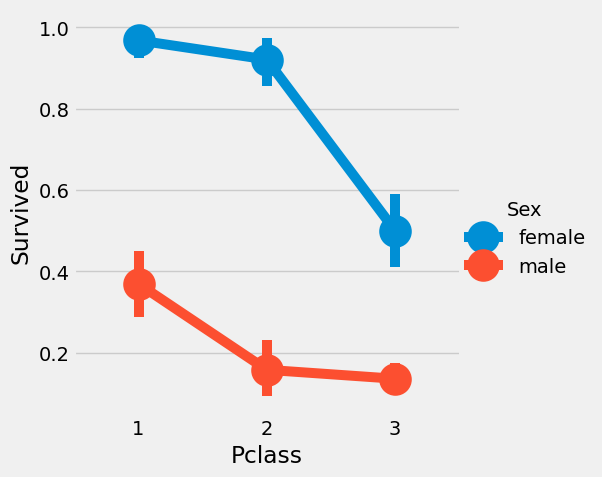

In [469]:
sns.catplot(data=data, x='Pclass', y='Survived', hue='Sex', kind='point')
plt.show()

## 2.4 Age --> Continous Feature

### Вывод самого пожилого, самого молодового пассажира и средний возраст на судне.

In [470]:
print('Oldest Passenger was of:',data['Age'].max(),'Years')
print('Youngest Passenger was of:',data['Age'].min(),'Years')
print('Average Age on the ship:',data['Age'].mean(),'Years')

Oldest Passenger was of: 80.0 Years
Youngest Passenger was of: 0.42 Years
Average Age on the ship: 29.69911764705882 Years


### Распределение выживаемости в зависимости от 
### 1) возраста и класса;
### 2) от пола и возраста.

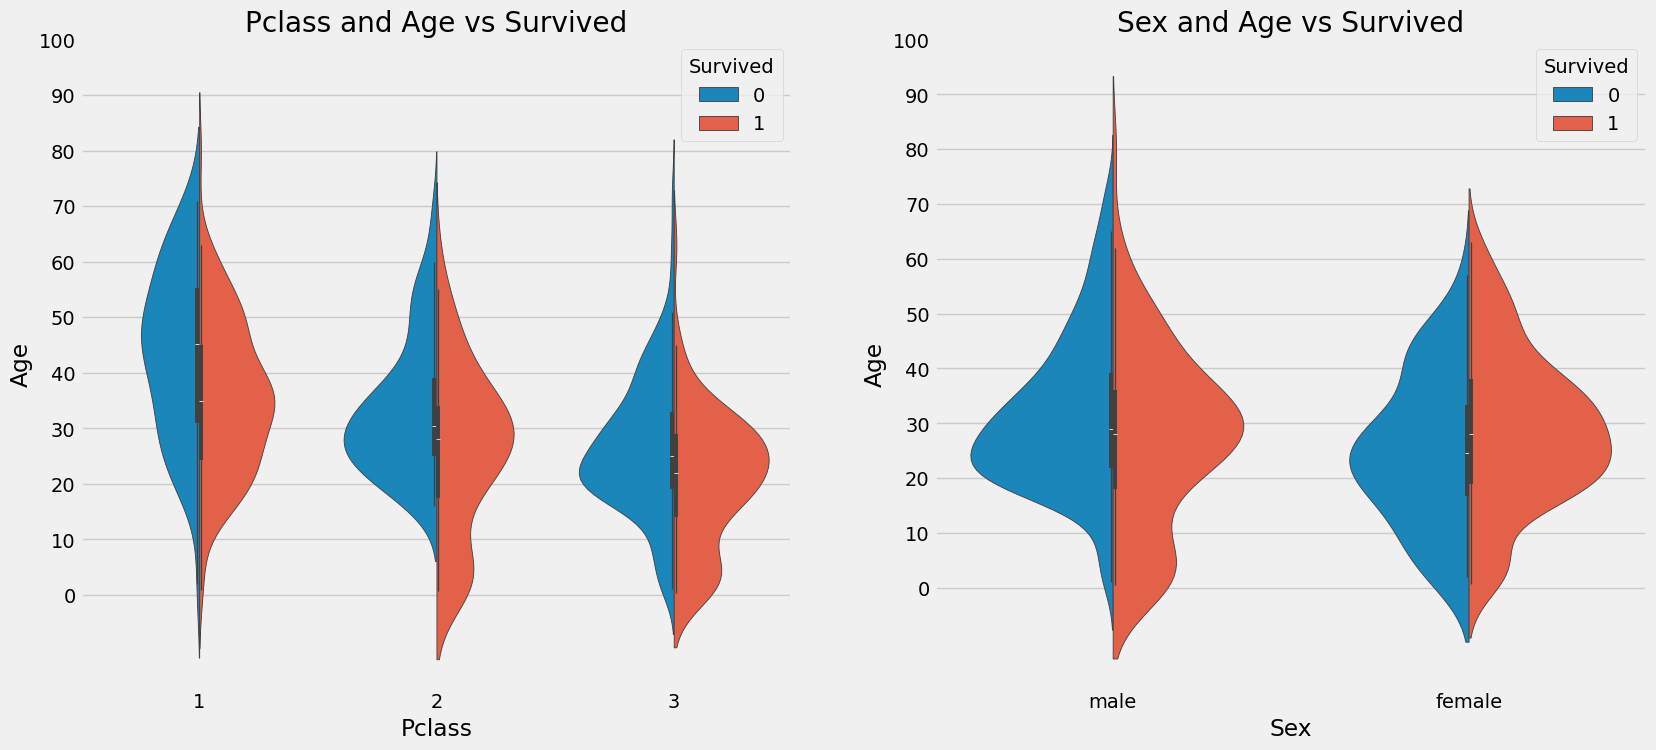

In [471]:
f,ax=plt.subplots(1,2,figsize=(18,8))
sns.violinplot(
    data=data,
    x = "Pclass",
    y = "Age",
    hue="Survived", 
    split=True,
    ax=ax[0]
)
ax[0].set_title('Pclass and Age vs Survived')
ax[0].set_yticks(range(0,110,10))

sns.violinplot(
    data=data,
    x = "Sex",
    y = "Age",
    hue="Survived", 
    split=True,
    ax=ax[1]
)
ax[1].set_title('Sex and Age vs Survived')
ax[1].set_yticks(range(0,110,10))
plt.show()

> ### Observations:

#### 1)The number of children increases with Pclass and the survival rate for passenegers below Age 10(i.e children) looks to be good irrespective of the Pclass.
#### 2)Survival chances for Passenegers aged 20-50 from Pclass1 is high and is even better for Women.
#### 3)For males, the survival chances decreases with an increase in age.

## 2.4.1 Работа с пропусками Age.
## Можно попробовать дать значение среднего возраста тем пассажирам, у которых есть в начале Mr или Ms. 

In [472]:
data['Initial'] = data['Name'].str.extract(r'([A-Za-z]+)\.')

### У кого какие приставки перед именем

In [473]:
data['Initial'].value_counts()

Initial
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Mlle          2
Major         2
Col           2
Countess      1
Capt          1
Ms            1
Sir           1
Lady          1
Mme           1
Don           1
Jonkheer      1
Name: count, dtype: int64

### Проверка, что не потеряли никакую запись (должно быть 891).

In [474]:
data['Initial'].value_counts().sum()

np.int64(891)

### Смотрим какие приставки какому полу принадлежат.

In [475]:
pd.crosstab(
    data.Initial,
    data.Sex,
    margins=True
).T.style.background_gradient(cmap='summer_r') #Checking the Initials with the Sex

Initial,Capt,Col,Countess,Don,Dr,Jonkheer,Lady,Major,Master,Miss,Mlle,Mme,Mr,Mrs,Ms,Rev,Sir,All
Sex,,,,,,,,,,,,,,,,,,
female,0,0,1,0,1,0,1,0,0,182,2,1,0,125,1,0,0,314
male,1,2,0,1,6,1,0,2,40,0,0,0,517,0,0,6,1,577
All,1,2,1,1,7,1,1,2,40,182,2,1,517,125,1,6,1,891


### Замечаем, что есть опечатки.

#### There are some misspelled Initials like Mlle or Mme that stand for Miss. I will replace them with Miss and same thing for other values.

In [476]:
# inplace=True
# Означает: заменить значения сразу внутри data['Initial'].
data['Initial'].replace(['Mlle','Mme','Ms','Dr','Major','Lady','Countess','Jonkheer','Col','Rev','Capt','Sir','Don'],
                        ['Miss','Miss','Miss','Mr','Mr','Mrs','Mrs','Other','Other','Other','Mr','Mr','Mr'],inplace=True)
data['Initial']

0         Mr
1        Mrs
2       Miss
3        Mrs
4         Mr
       ...  
886    Other
887     Miss
888     Miss
889       Mr
890       Mr
Name: Initial, Length: 891, dtype: object

### Находим среднии значения по "титулам".

In [477]:
data.groupby('Initial')['Age'].mean() #lets check the average age by Initials

Initial
Master     4.574167
Miss      21.860000
Mr        32.739609
Mrs       35.981818
Other     45.888889
Name: Age, dtype: float64

### Master — это не профессия и не статус взрослого мужчины. В старой английской традиции Master использовали как обращение к мальчику, обычно до совершеннолетия.

> ### Даём этим группам их средний возраст, чтобы не терять эту информацию.

In [478]:
# Assigning the NaN Values with the Ceil values of the mean ages
# data.loc[условие, 'столбец, который нужно заменить']
data.loc[(data.Age.isnull())&(data.Initial=='Mr'),'Age']=33
data.loc[(data.Age.isnull())&(data.Initial=='Mrs'),'Age']=36
data.loc[(data.Age.isnull())&(data.Initial=='Master'),'Age']=5
data.loc[(data.Age.isnull())&(data.Initial=='Miss'),'Age']=22
data.loc[(data.Age.isnull())&(data.Initial=='Other'),'Age']=46

### Проверка как заполнились пропуски.

In [479]:
data.Age.isnull().any()
# Должно быть False

np.False_

### Выводим распределение выживших по возрасту.
### Чтобы информация не выглядела шумно разбиваем все возраста на 20 bins по возрасту от 0 до максимального возраста.

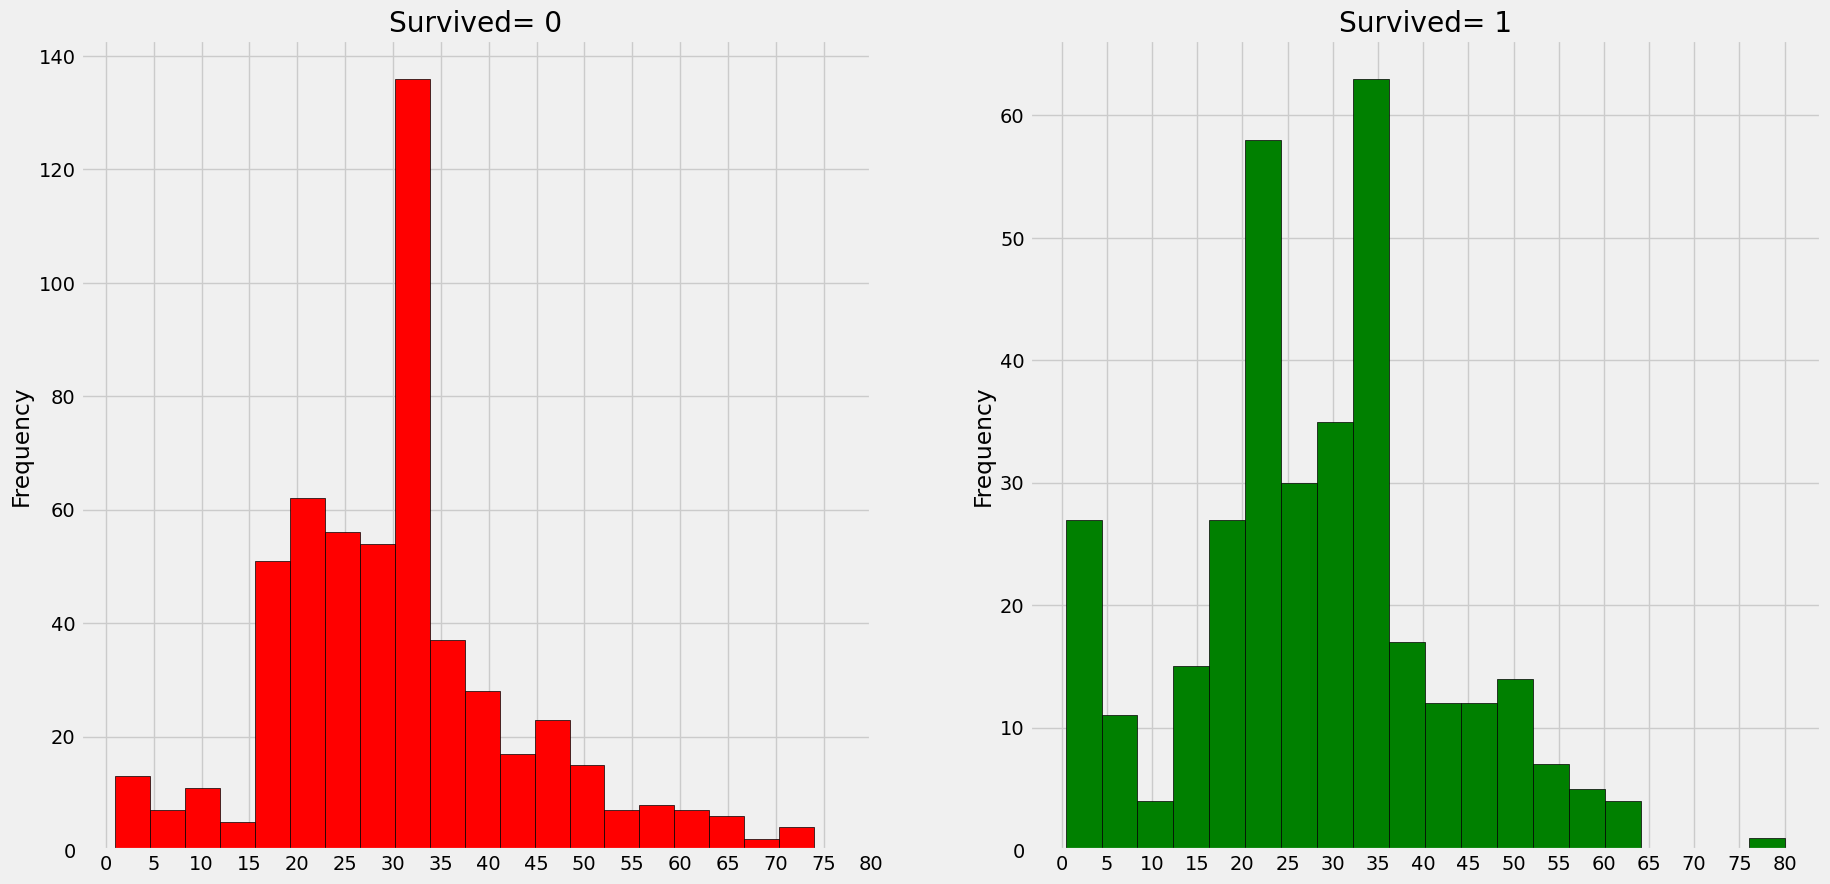

In [480]:
f,ax=plt.subplots(1,2,figsize=(20,10))
data[data['Survived']==0].Age.plot.hist(ax=ax[0],bins=20,edgecolor='black',color='red')
ax[0].set_title('Survived= 0')
x1=list(range(0,85,5))
ax[0].set_xticks(x1)

data[data['Survived']==1].Age.plot.hist(ax=ax[1],color='green',bins=20,edgecolor='black')
ax[1].set_title('Survived= 1')
x2=list(range(0,85,5))
ax[1].set_xticks(x2)
plt.show()

> ### Observations:

### 1)The Toddlers(age<5) were saved in large numbers(The Women and Child First Policy).
### 2)The oldest Passenger was saved(80 years).
### 3)Maximum number of deaths were in the age group of 30-40.

### Зависимость выживаемости от "титула и класса".

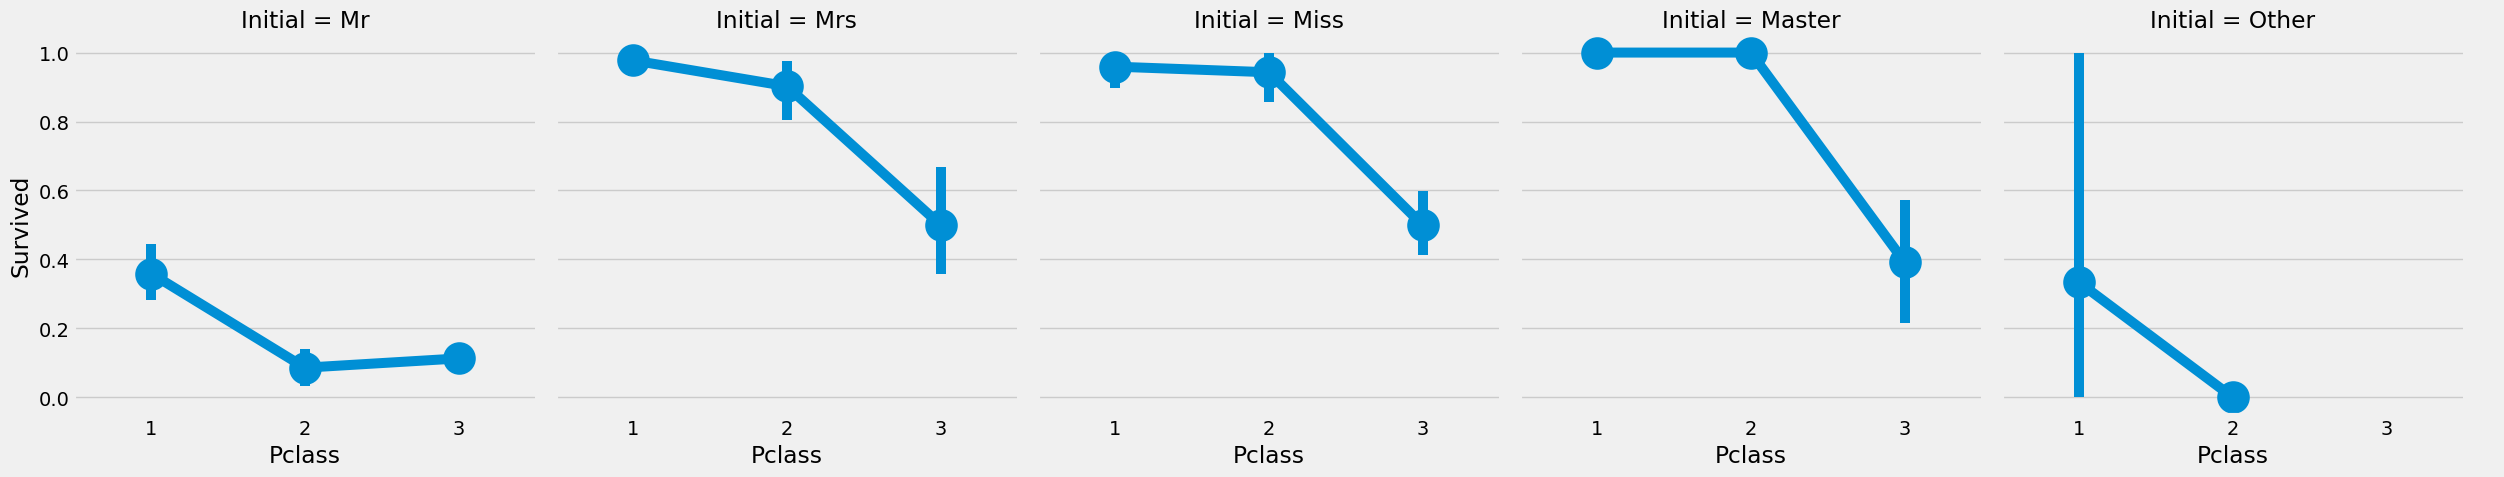

In [481]:
sns.catplot(
    data=data,
    x='Pclass',
    y='Survived',
    col='Initial',
    kind='point'
)
plt.show()

> ### The Women and Child first policy thus holds true irrespective of the class.

## 2.5 Embarked--> Categorical Value

### Сколько пассажиров по классам в каком порту сели и какого они были при этом пола.

In [482]:
pd.crosstab([data.Embarked,data.Pclass],[data.Sex,data.Survived],margins=True).style.background_gradient(cmap='summer_r')

### Видно, что больше всего пассажиров село в Southampton и при этом большинство из них было 3 класса.

### Chances for Survival by Port Of Embarkation

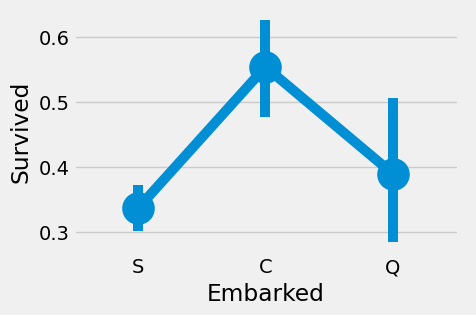

In [483]:
# Создание графика.
sns.catplot(data=data, x='Embarked',y='Survived',kind='point')
# Эта строка сохраняет объект текущего графика в переменную fig, чтобы дальше менять его настройки.
fig=plt.gcf()
fig.set_size_inches(5,3)
plt.show()

### The chances for survival for Port C is highest around 0.55 while it is lowest for S.

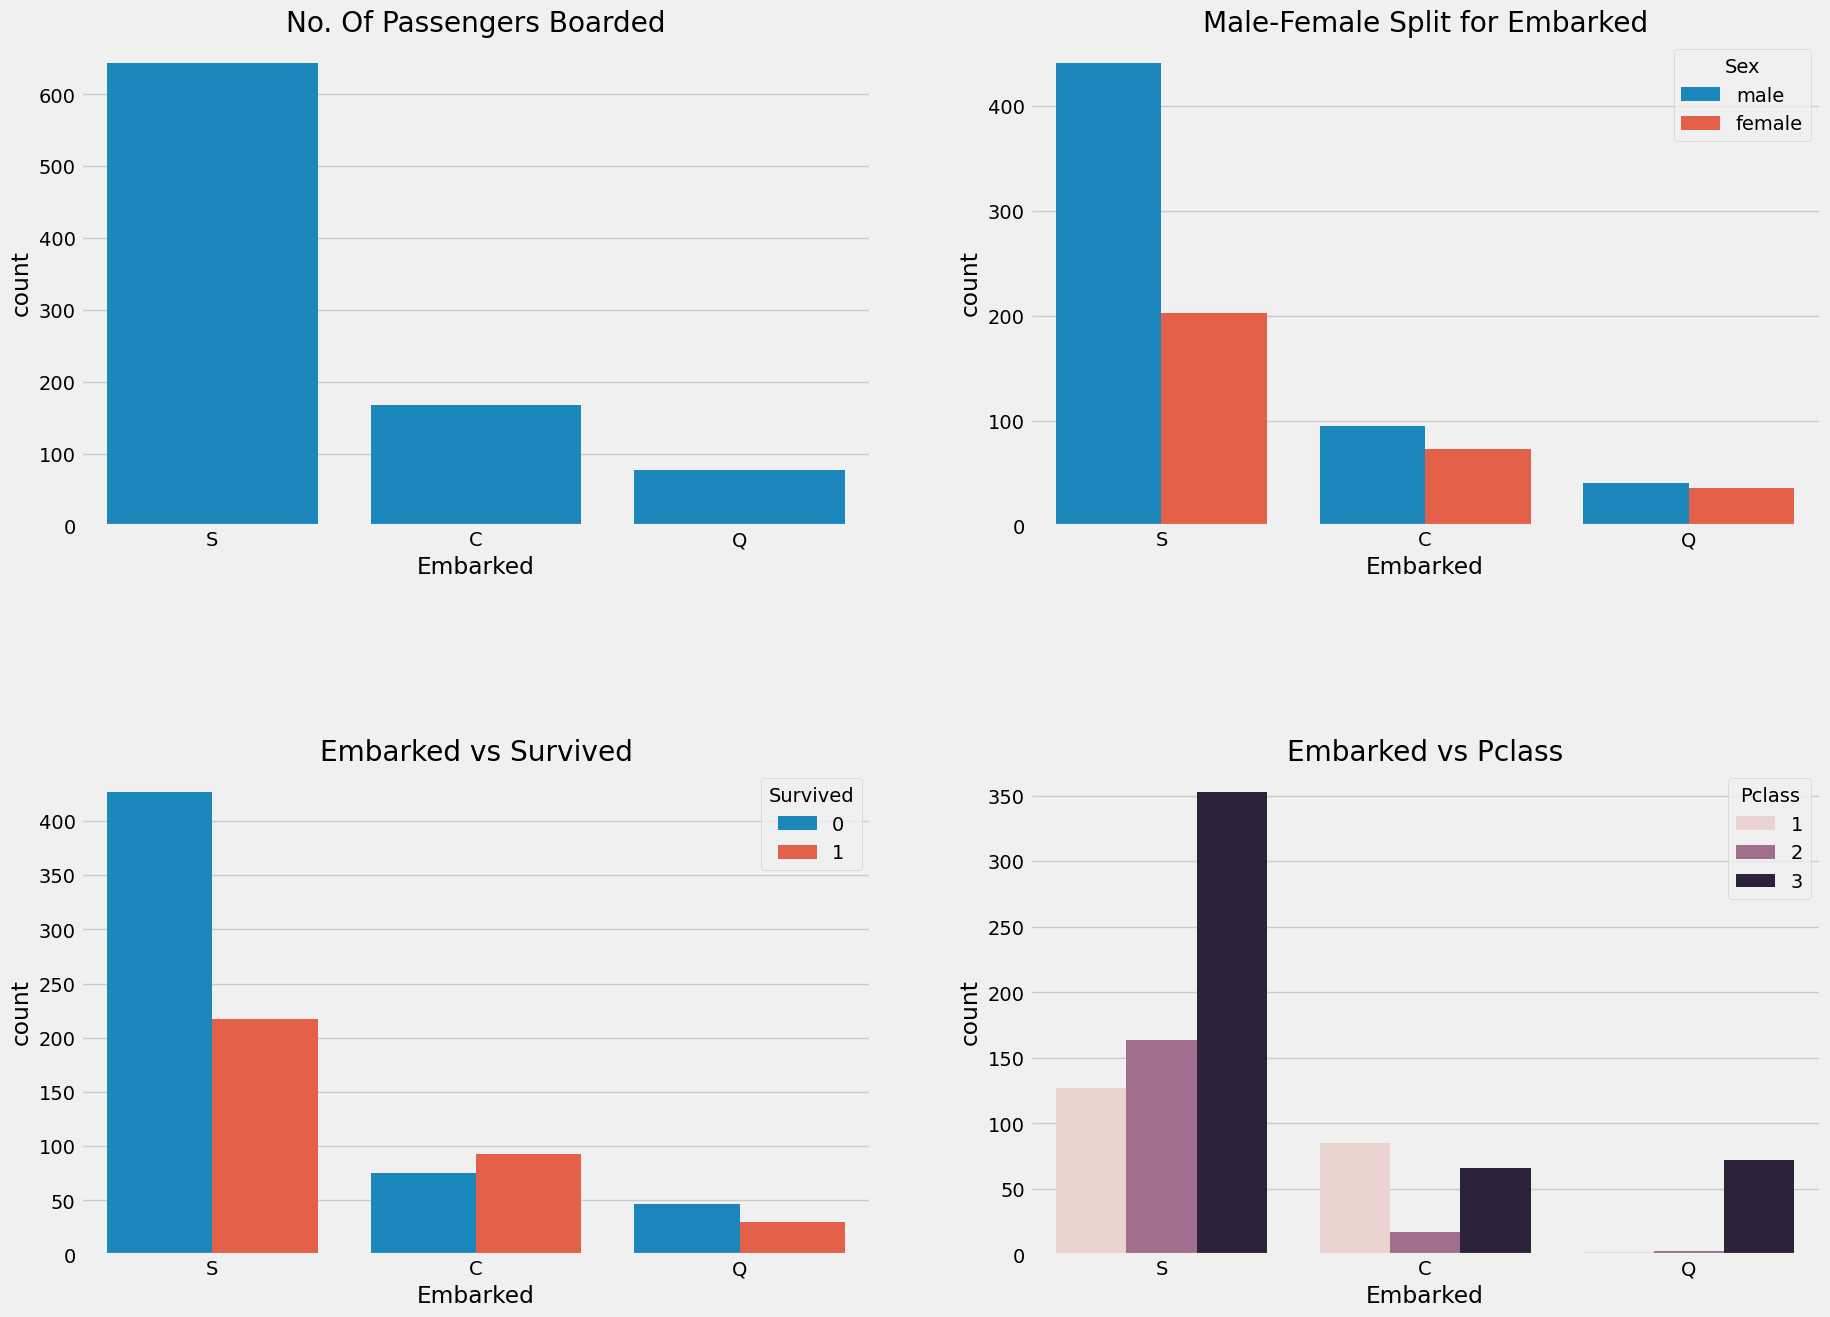

In [484]:
f,ax=plt.subplots(2,2,figsize=(20,15))
sns.countplot(data=data, x='Embarked', ax=ax[0,0])
ax[0,0].set_title('No. Of Passengers Boarded')

sns.countplot(data=data, x='Embarked', hue='Sex', ax=ax[0,1])
ax[0,1].set_title('Male-Female Split for Embarked')

sns.countplot(data=data, x='Embarked', hue='Survived', ax=ax[1,0])
ax[1,0].set_title('Embarked vs Survived')

sns.countplot(data=data, x='Embarked', hue='Pclass', ax=ax[1,1])
ax[1,1].set_title('Embarked vs Pclass')

plt.subplots_adjust(wspace=0.2,hspace=0.5)
plt.show()

> ### Observations:¶

### 1)Maximum passengers boarded from S. Majority of them being from Pclass3.

### 2)The Passengers from C look to be lucky as a good proportion of them survived. The reason for this maybe the rescue of all the Pclass1 and Pclass2 Passengers.

### 3)The Embark S looks to the port from where majority of the rich people boarded. Still the chances for survival is low here, that is because many passengers from Pclass3 around 81% didn't survive.

### 4)Port Q had almost 95% of the passengers were from Pclass3.

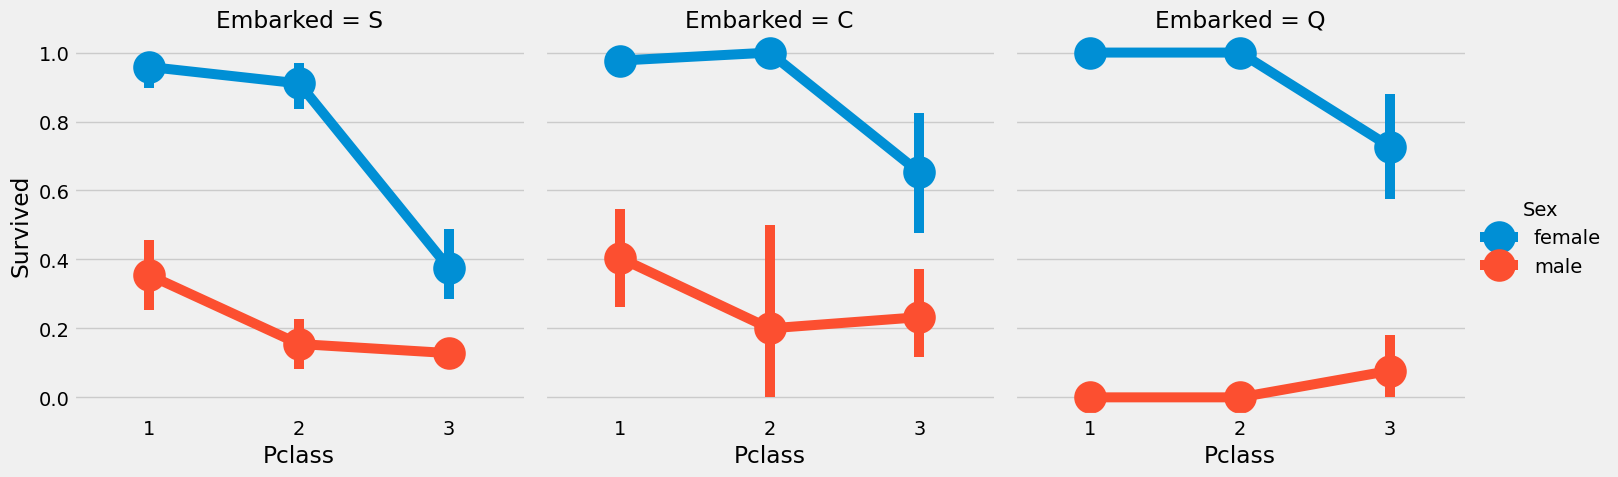

In [485]:
sns.catplot(data=data, x='Pclass',y='Survived',hue='Sex',col='Embarked', kind='point')
plt.show()

> ### Observations:

### 1)The survival chances are almost 1 for women for Pclass1 and Pclass2 irrespective of the Pclass.

### 2)Port S looks to be very unlucky for Pclass3 Passenegers as the survival rate for both men and women is very low.(Money Matters)

### 3)Port Q looks looks to be unlukiest for Men, as almost all were from Pclass 3.

## 2.5.1 Filling Embarked NaN. As we saw that maximum passengers boarded from Port S, we replace NaN with S.

In [486]:
data['Embarked'].fillna('S',inplace=True)

In [487]:
# Проверка
data.Embarked.isnull().any()# Finally No NaN values - False

np.False_

## 2.6. SibSip --> Discrete Feature

### This feature represents whether a person is alone or with his family members.
### Sibling = brother, sister, stepbrother, stepsister
### Spouse = husband, wife

In [488]:
pd.crosstab([data.SibSp],data.Survived).style.background_gradient(cmap='summer_r')

Survived,0,1
SibSp,,
0,398,210
1,97,112
2,15,13
3,12,4
4,15,3
5,5,0
8,7,0


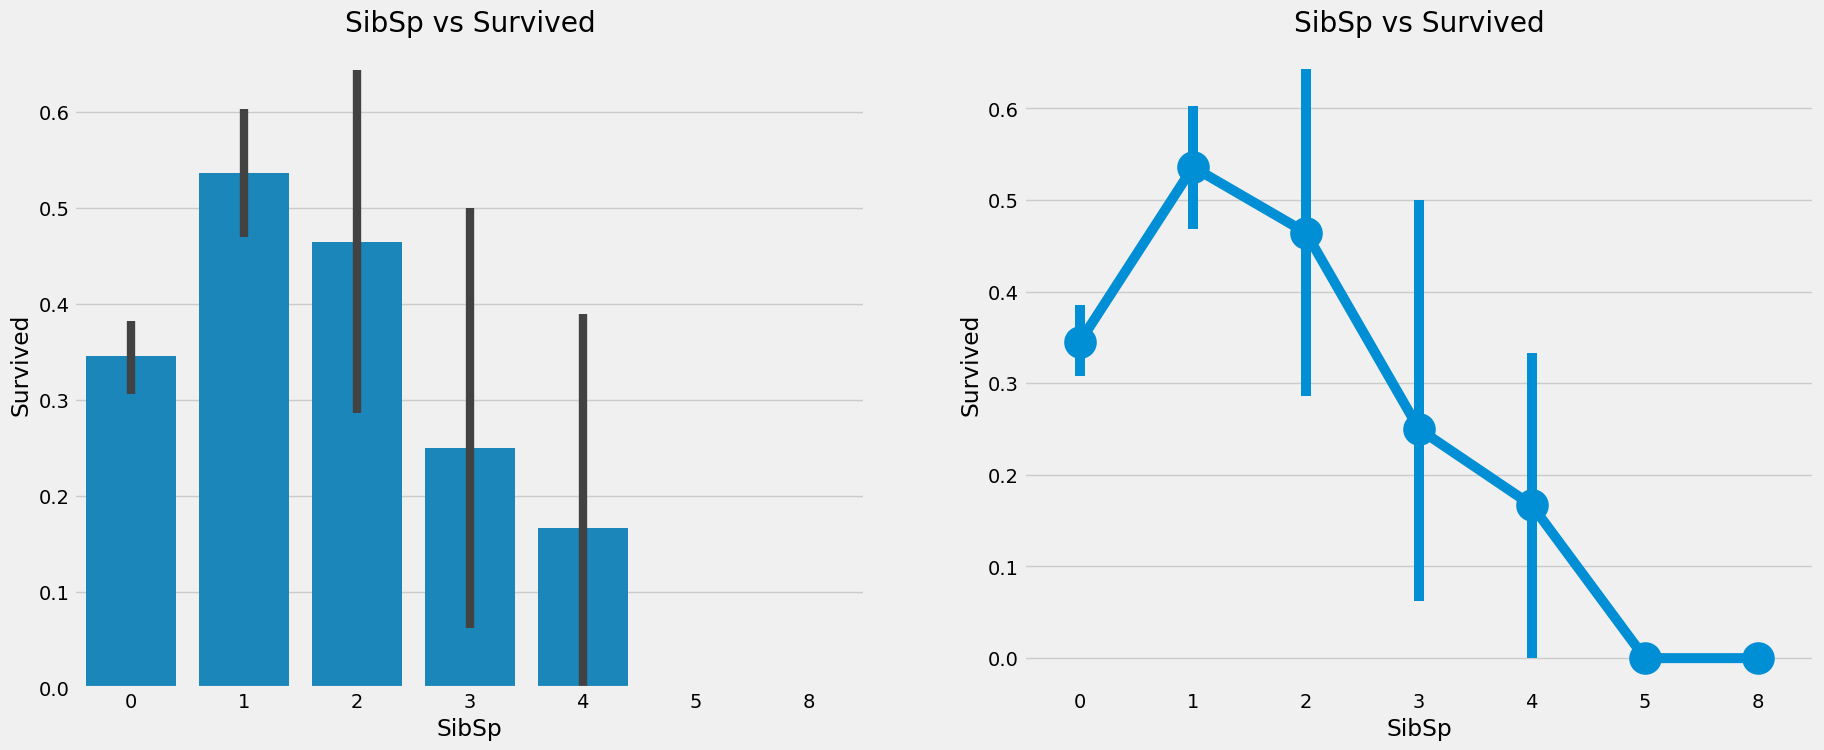

In [489]:
f, ax = plt.subplots(1, 2, figsize=(20, 8))

sns.barplot(data=data, x='SibSp', y='Survived', ax=ax[0])
ax[0].set_title('SibSp vs Survived')

sns.pointplot(data=data, x='SibSp', y='Survived', ax=ax[1])
ax[1].set_title('SibSp vs Survived')

plt.show()

#### Черные вертикальные полоски — это error bars: 95% доверительный интервал
#### для среднего значения Survived в каждой группе. Чем меньше данных в группе,
#### тем обычно шире интервал и тем менее надежна оценка среднего.

**95% доверительный интервал для среднего:**

$$
CI_{95\%} = \bar{x} \pm 1.96 \cdot \frac{s}{\sqrt{n}}
$$

где $\bar{x}$ — среднее значение, $s$ — стандартное отклонение выборки, $n$ — количество наблюдений в группе.

In [490]:
pd.crosstab(data.SibSp,data.Pclass).style.background_gradient(cmap='summer_r')

Pclass,1,2,3
SibSp,,,
0,137,120,351
1,71,55,83
2,5,8,15
3,3,1,12
4,0,0,18
5,0,0,5
8,0,0,7


> ### Observations:

### The barplot and pointplot shows that if a passenger is alone onboard with no siblings, he have 34.5% survival rate. The graph roughly decreases if the number of siblings increase. This makes sense. That is, if I have a family on board, I will try to save them instead of saving myself first. Surprisingly the survival for families with 5-8 members is 0%.

### The reason is Pclass. The crosstab shows that Person with SibSp>3 were all in Pclass3. It is imminent that all the large families in Pclass3(>3) died.

## 2.7. Parch - parents and children.

In [491]:
pd.crosstab(data.Parch, data.Pclass).style.background_gradient(cmap='summer_r')

Pclass,1,2,3
Parch,,,
0,163,134,381
1,31,32,55
2,21,16,43
3,0,2,3
4,1,0,3
5,0,0,5
6,0,0,1


### The crosstab again shows that larger families were in Pclass3.

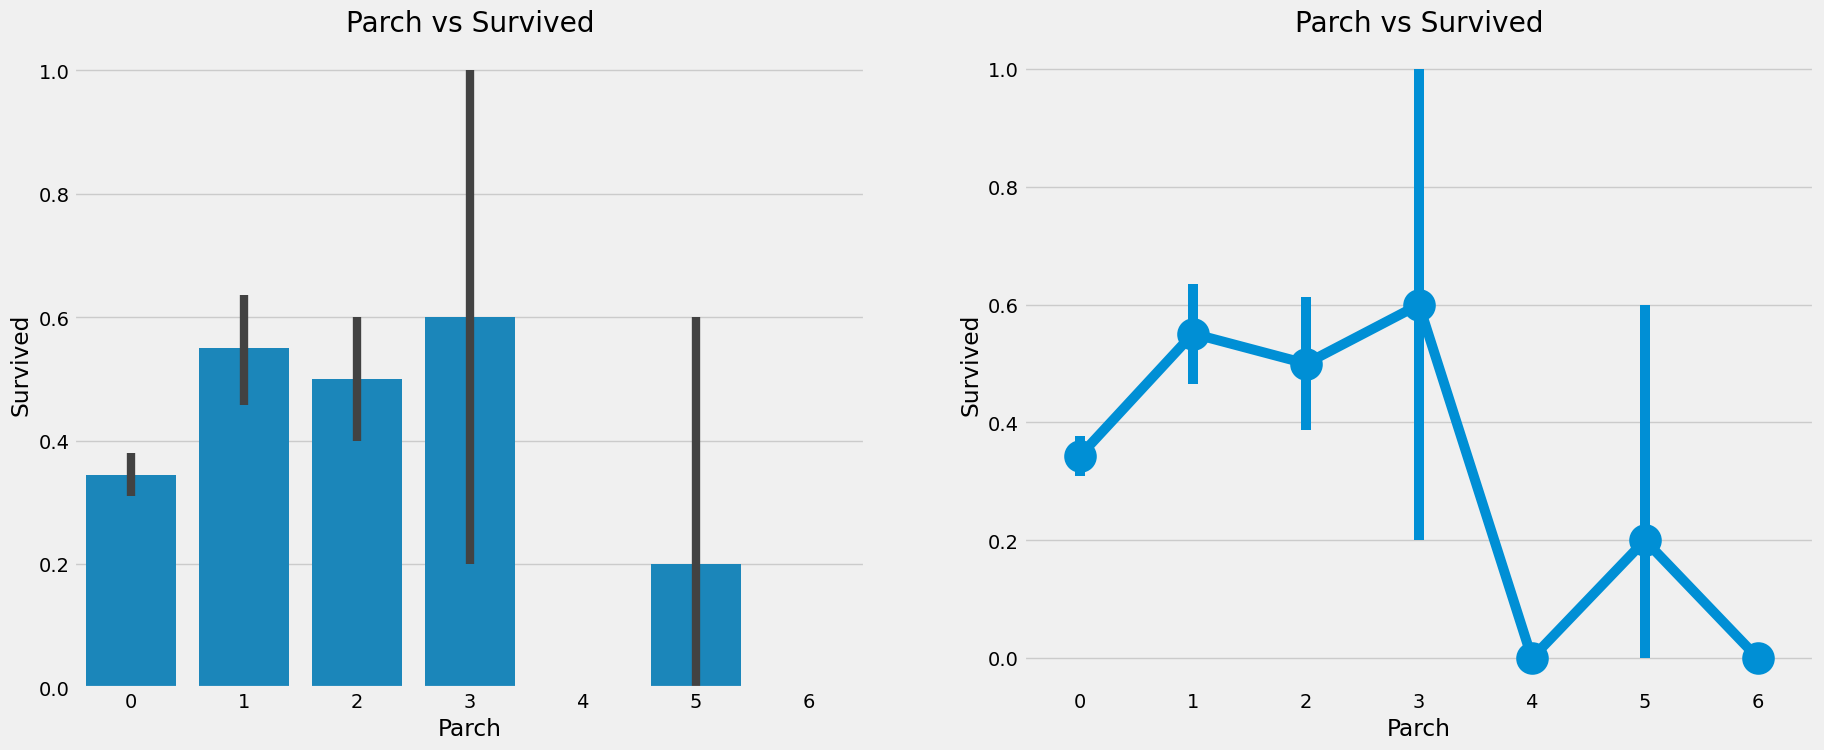

In [492]:
f,ax=plt.subplots(1,2,figsize=(20,8))

sns.barplot(data=data, x='Parch', y='Survived', ax=ax[0])
ax[0].set_title('Parch vs Survived')

sns.pointplot(data=data, x='Parch', y='Survived', ax=ax[1])
ax[1].set_title('Parch vs Survived')

plt.show()

> ### Observations:

### Here too the results are quite similar. Passengers with their parents onboard have greater chance of survival. It however reduces as the number goes up.

### The chances of survival is good for somebody who has 1-3 parents on the ship. Being alone also proves to be fatal and the chances for survival decreases when somebody has >4 parents on the ship.

## 2.9 Fare --> Continous Feature

### Вывод максимального, минимального и среднего чека.

In [493]:
print('Highest Fare was:',data['Fare'].max())
print('Lowest Fare was:',data['Fare'].min())
print('Average Fare was:',data['Fare'].mean())

Highest Fare was: 512.3292
Lowest Fare was: 0.0
Average Fare was: 32.204207968574636


#### Больше всего денег принёс первый класс.

In [494]:
data.groupby('Pclass')['Fare'].sum()

Pclass
1    18177.4125
2     3801.8417
3     6714.6951
Name: Fare, dtype: float64

### Распределение чеков по классам. Внутри класса каюты стоили по разному.

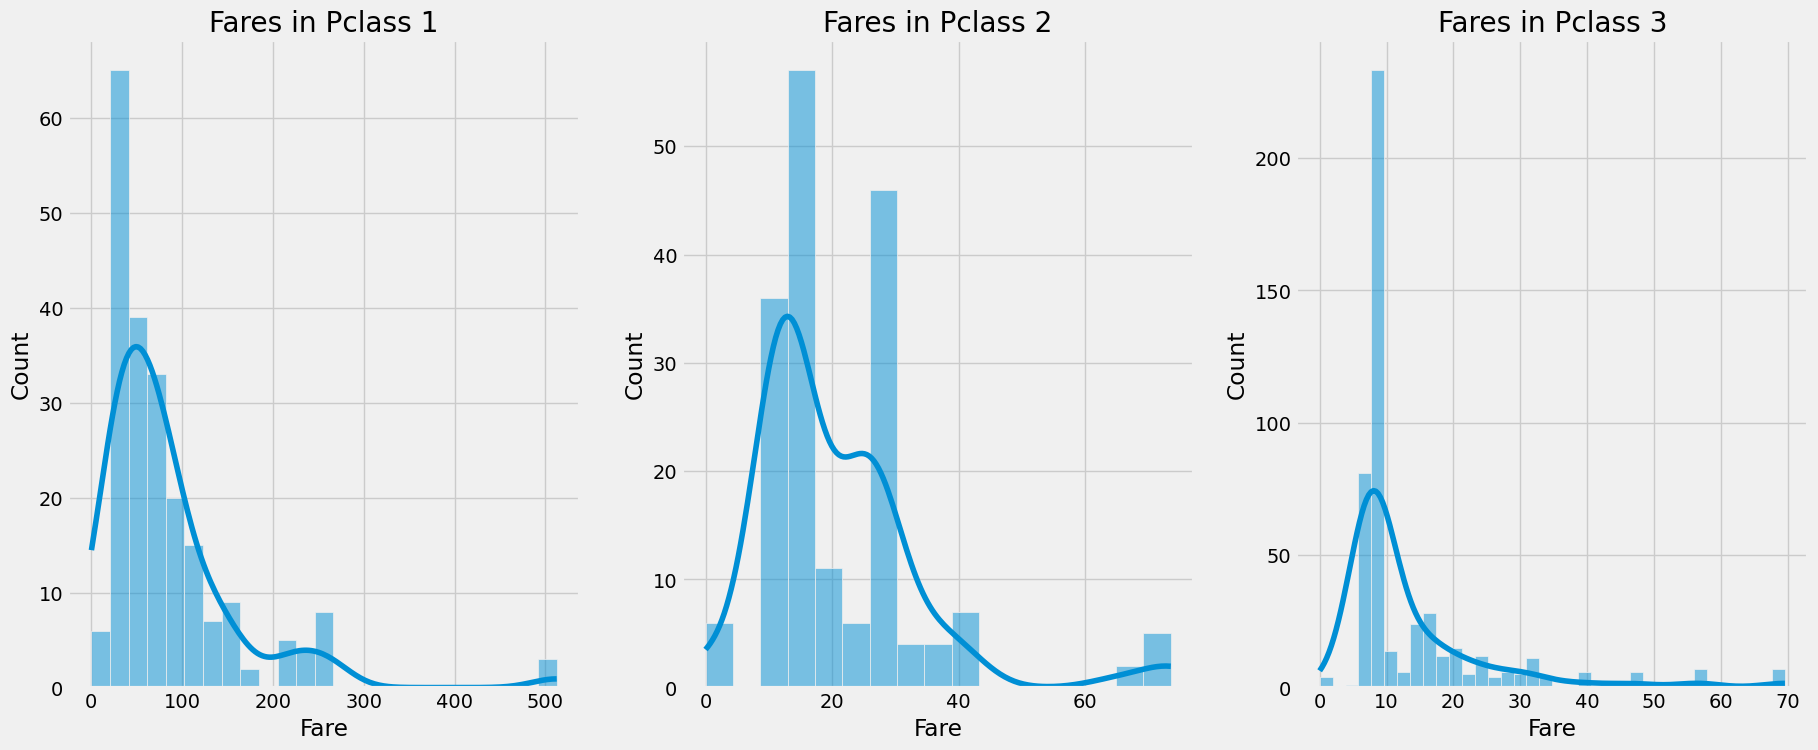

In [495]:
f, ax = plt.subplots(1, 3, figsize=(20, 8))

for i, pclass in enumerate([1, 2, 3]):
    sns.histplot(
        data=data[data['Pclass'] == pclass],
        x='Fare',
        # kde=True — добавляет плавную линию распределения поверх гистограммы
        kde=True,
        ax=ax[i]
    )
    ax[i].set_title(f'Fares in Pclass {pclass}')

plt.show()

### Fare — цена билета.
### У пассажиров 1 класса цены билетов сильно различались: кто-то заплатил относительно немного, а кто-то очень много за дорогую каюту.
### У пассажиров 2 и особенно 3 класса цены обычно были более похожи друг на друга, поэтому разброс меньше.
### Fare — непрерывный числовой признак: теоретически цена может быть 7.25, 13.50, 26.00, 80.75 и т.д.
### Можно сделать binning — разбить цены на интервалы, то есть категории. 
### => Выживали ли пассажиры с дешёвыми, средними и дорогими билетами по-разному? Binning , также защитит от выбросов.

# 3. Вывод по EDA
## Observations in a Nutshell for all features:¶
### Sex:
The chance of survival for women is high as compared to men.

### Pclass:
There is a visible trend that being a 1st class passenger gives you better chances of survival. The survival rate for Pclass3 is very low. For women, the chance of survival from Pclass1 is almost 1 and is high too for those from Pclass2. Money Wins!!!.

### Age:
Children less than 5-10 years do have a high chance of survival. Passengers between age group 15 to 35 died a lot.

### Embarked:
This is a very interesting feature. The chances of survival at C looks to be better than even though the majority of Pclass1 passengers got up at S. Passengers at Q were all from Pclass3.

### Parch+SibSp:
Having 1-2 siblings,spouse on board or 1-3 Parents shows a greater chance of probablity rather than being alone or having a large family travelling with you.

# 4. Correlation Between The Features

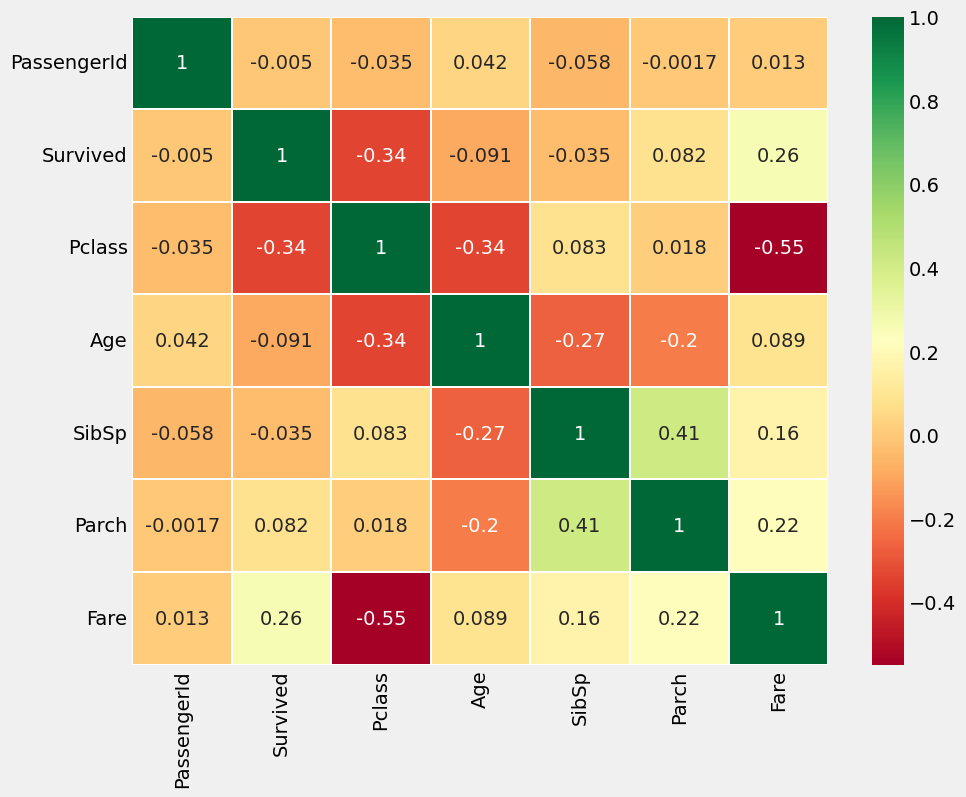

In [496]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    data.corr(numeric_only=True),
    annot=True,
    cmap='RdYlGn',
    linewidths=0.2
)

plt.show()

### **Interpreting The Heatmap**¶

#### The first thing to note is that only the numeric features are compared as it is obvious that we cannot correlate between alphabets or strings. Before understanding the plot, let us see what exactly correlation is.

### **POSITIVE CORRELATION**:
### If an increase in feature A leads to increase in feature B, then they are positively correlated. A value 1 means perfect positive correlation
### **NEGATIVE CORRELATION**:
### If an increase in feature A leads to decrease in feature B, then they are negatively correlated. A value -1 means perfect negative correlation.
### Now lets say that two features are highly or perfectly correlated, so the increase in one leads to increase in the other. This means that both the features are containing highly similar information and there is very little or no variance in information. This is known as **MultiColinearity** as both of them contains almost the same information.
### So do you think we should use both of them as **one of them is redundant.** While making or training models, we should try to eliminate redundant features as it reduces training time and many such advantages.
### Now from the above heatmap,we can see that the features are not much correlated. The highest correlation is between **SibSp and Parch i.e 0.41.**
> # So we can carry on with all features.


---

# Part 2. Feature Engineering and Data Cleaning

## 1. Age_band. Age binning.

### The maximum age of a passenger was 80.
### Lets divide the range from 0-80 into 5 bins. So 80/5=16. So bins of size 16.

### => получуится **5 возрастных групп.**

In [497]:
# Создаём новый признак.
data['Age_band']=0
data.loc[data['Age']<=16,'Age_band']=0
data.loc[(data['Age']>16)&(data['Age']<=32),'Age_band']=1
data.loc[(data['Age']>32)&(data['Age']<=48),'Age_band']=2
data.loc[(data['Age']>48)&(data['Age']<=64),'Age_band']=3
data.loc[data['Age']>64,'Age_band']=4
data.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Initial,Age_band
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr,2


### Checking the number of passenegers in each band

In [498]:
data['Age_band'].value_counts().to_frame().style.background_gradient(cmap='summer')

,count
Age_band,
1,382
2,325
0,104
3,69
4,11


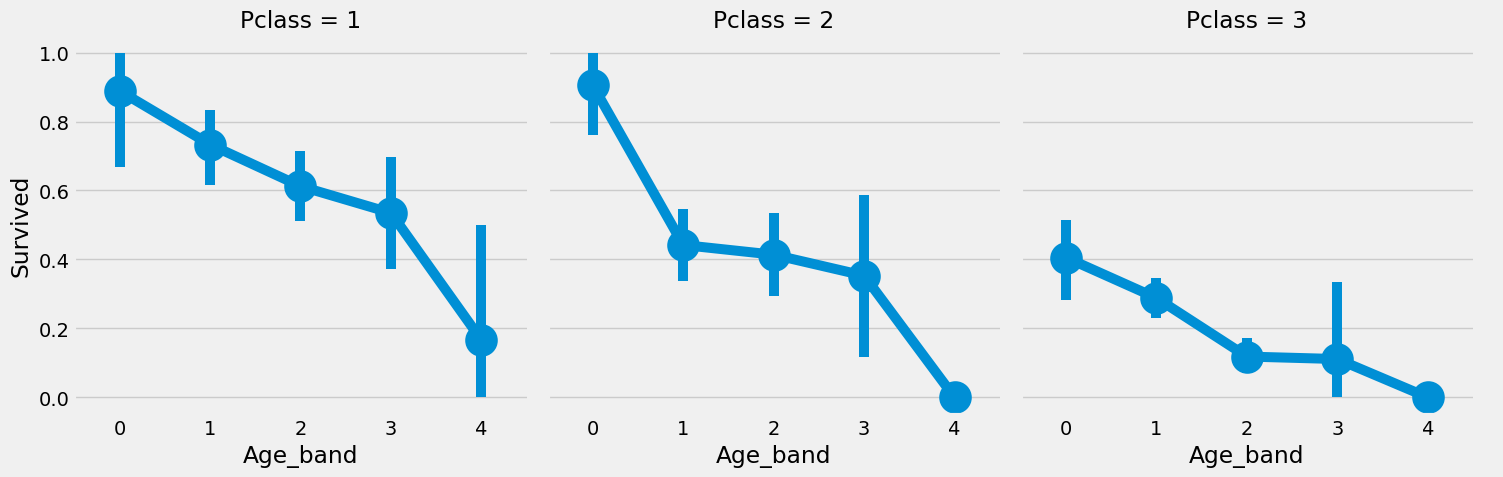

In [499]:
sns.catplot(data=data, x='Age_band', y='Survived', col='Pclass', kind ='point')
plt.show()

> ### Observation:
### The survival rate decreases as the age increases irrespective of the Pclass.

# 2. Family_Size and Alone.

### At this point, we can create a new feature called **"Family_size" and "Alone"** and analyse it. This feature is the summation of Parch and SibSp. It gives us a combined data so that we can check if survival rate have anything to do with family size of the passengers. Alone will denote whether a passenger is alone or not.

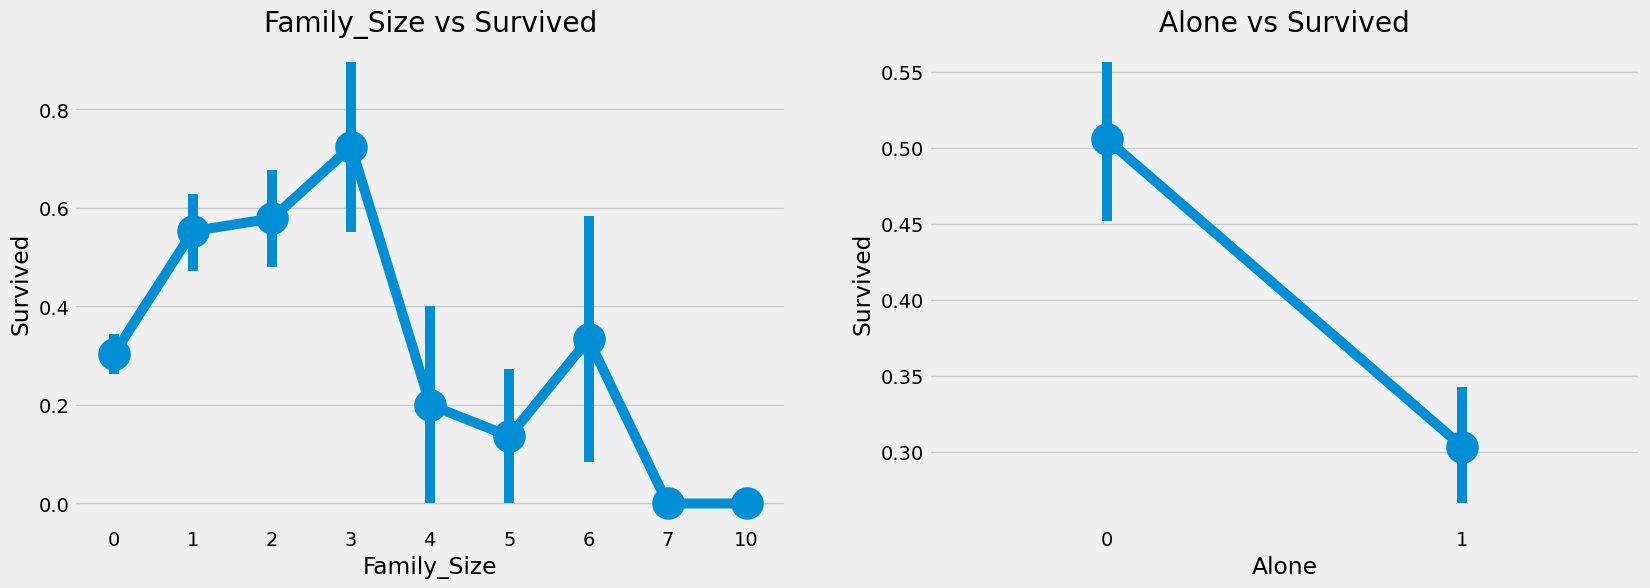

In [500]:
# Создаём новый признак
data['Family_Size']=0
data['Family_Size']=data['Parch']+data['SibSp'] # family size без самого пассажира.

data['Alone'] = 0
data.loc[data.Family_Size==0, 'Alone'] = 1 # Alone.

f,ax=plt.subplots(1,2,figsize=(18,6))

sns.pointplot(data=data, x='Family_Size',y='Survived', ax=ax[0])
ax[0].set_title('Family_Size vs Survived')

sns.pointplot(data=data, x='Alone',y='Survived', ax=ax[1])
ax[1].set_title('Alone vs Survived')

plt.show()

> ### Observations:
### Family_Size=0 means that the passeneger is alone. Clearly, if you are alone or family_size=0,then chances for survival is very low. For family size > 4,the chances decrease too. This also looks to be an important feature for the model. Lets examine this further.

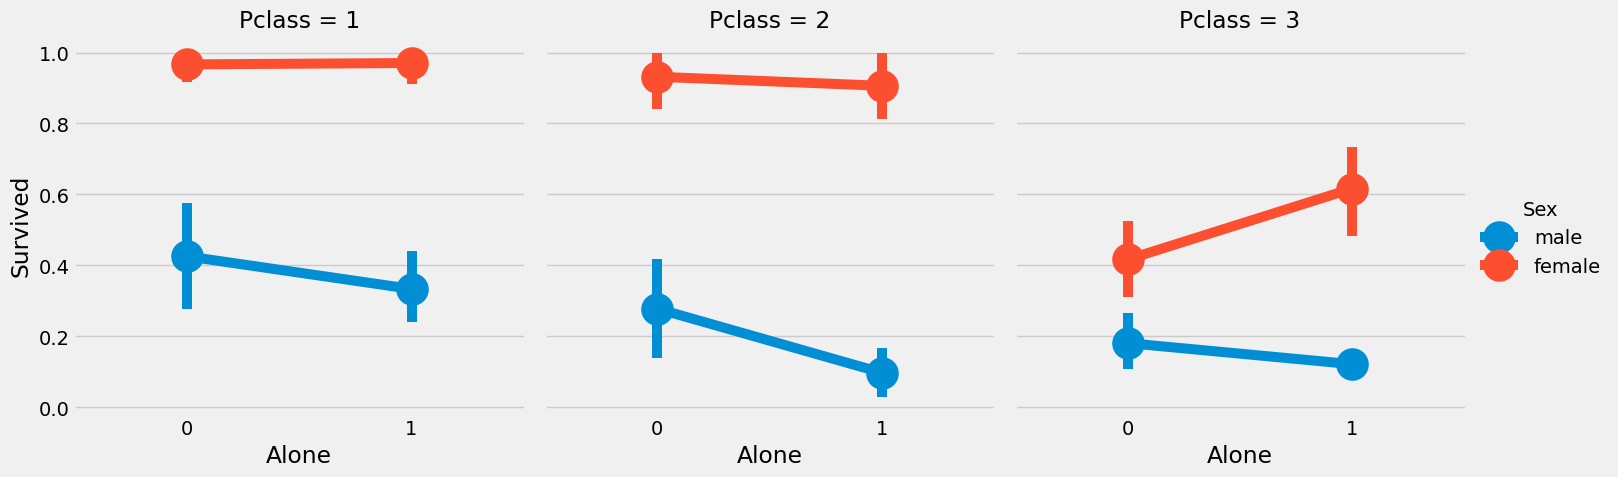

In [501]:
sns.catplot(data=data, x='Alone', y='Survived', hue='Sex',col='Pclass', kind='point')
plt.show()

> ### Observations:
### It is visible that being alone is harmful irrespective of Sex or Pclass except for Pclass3 where the chances of females who are alone is high than those with family.

## 3. Fare_Range

### Since fare is also a continous feature, we need to convert it into ordinal value. For this we will use **pandas.qcut**.

### So what qcut does is it splits or arranges the values according the number of bins we have passed. So **if we pass for 5 bins, it will arrange the values equally spaced into 5 seperate bins** or value ranges.

### Получаются квартильные группы: самые дешевые билеты, ниже среднего, выше среднего, самые дорогие.

### Среднее значение Survived фактически означает долю выживших в группе.

In [502]:
data['Fare_Range']=pd.qcut(data['Fare'], 4)
data.groupby(['Fare_Range'])['Survived'].mean().to_frame().style.background_gradient(cmap='summer_r')

,Survived
Fare_Range,
"(-0.001, 7.91]",0.197309
"(7.91, 14.454]",0.303571
"(14.454, 31.0]",0.454955
"(31.0, 512.329]",0.581081


> ### Observations:
### The fare_range increases, the chances of survival increases.

### Now we cannot pass the Fare_Range values as it is.
### **Convertation Fare_Range values into singleton values** same as we did in Age_Band

In [503]:
data['Fare_cat']=0

data.loc[data['Fare']<=7.91,'Fare_cat']=0
data.loc[(data['Fare']>7.91)&(data['Fare']<=14.454),'Fare_cat']=1
data.loc[(data['Fare']>14.454)&(data['Fare']<=31),'Fare_cat']=2
data.loc[data['Fare']>31,'Fare_cat']=3

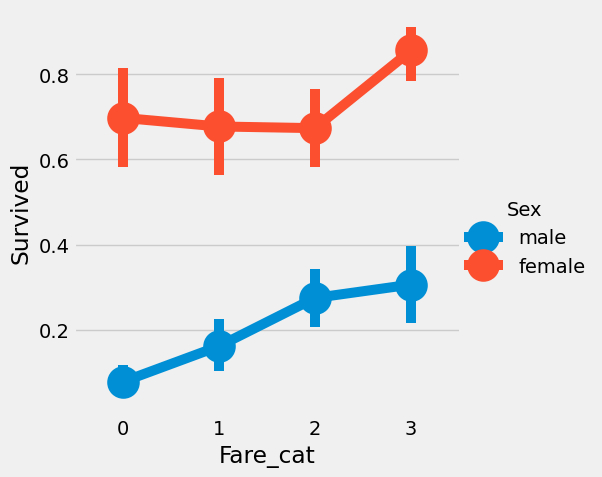

In [504]:
sns.catplot(data=data, x='Fare_cat',y='Survived', hue='Sex', kind='point')
plt.show()

> ### Observation:
### Clearly, **as the Fare_cat increases, the survival chances increases.** This feature may become an important feature during modeling along with the Sex.

## 4. Converting String Values into Numeric

### Since **we cannot pass strings to a machine learning model**, we need to convert features loke Sex, Embarked, etc into numeric values.

In [505]:
data['Sex'].replace(['male','female'],[0,1],inplace=True)
data['Embarked'].replace(['S','C','Q'],[0,1,2],inplace=True)
data['Initial'].replace(['Mr','Mrs','Miss','Master','Other'],[0,1,2,3,4],inplace=True)

### Но лучше всё таки использовать потом **one hot encoding**. Чтобы не вносить лишней информации, что Embarked или Initial могут быть больше или меньше друг друга.

### **Dropping UnNeeded Features**

**Name** --> We don't need name feature as it cannot be converted into any categorical value.

**Age** --> We have the Age_band feature, so no need of this.

**Ticket** --> It is any random string that cannot be categorised.

**Fare** --> We have the Fare_cat feature, so unneeded

**Cabin** --> A lot of NaN values and also many passengers have multiple cabins. So this is a useless feature.

**Fare_Range** --> We have the fare_cat feature.

**PassengerId** --> Cannot be categorised.

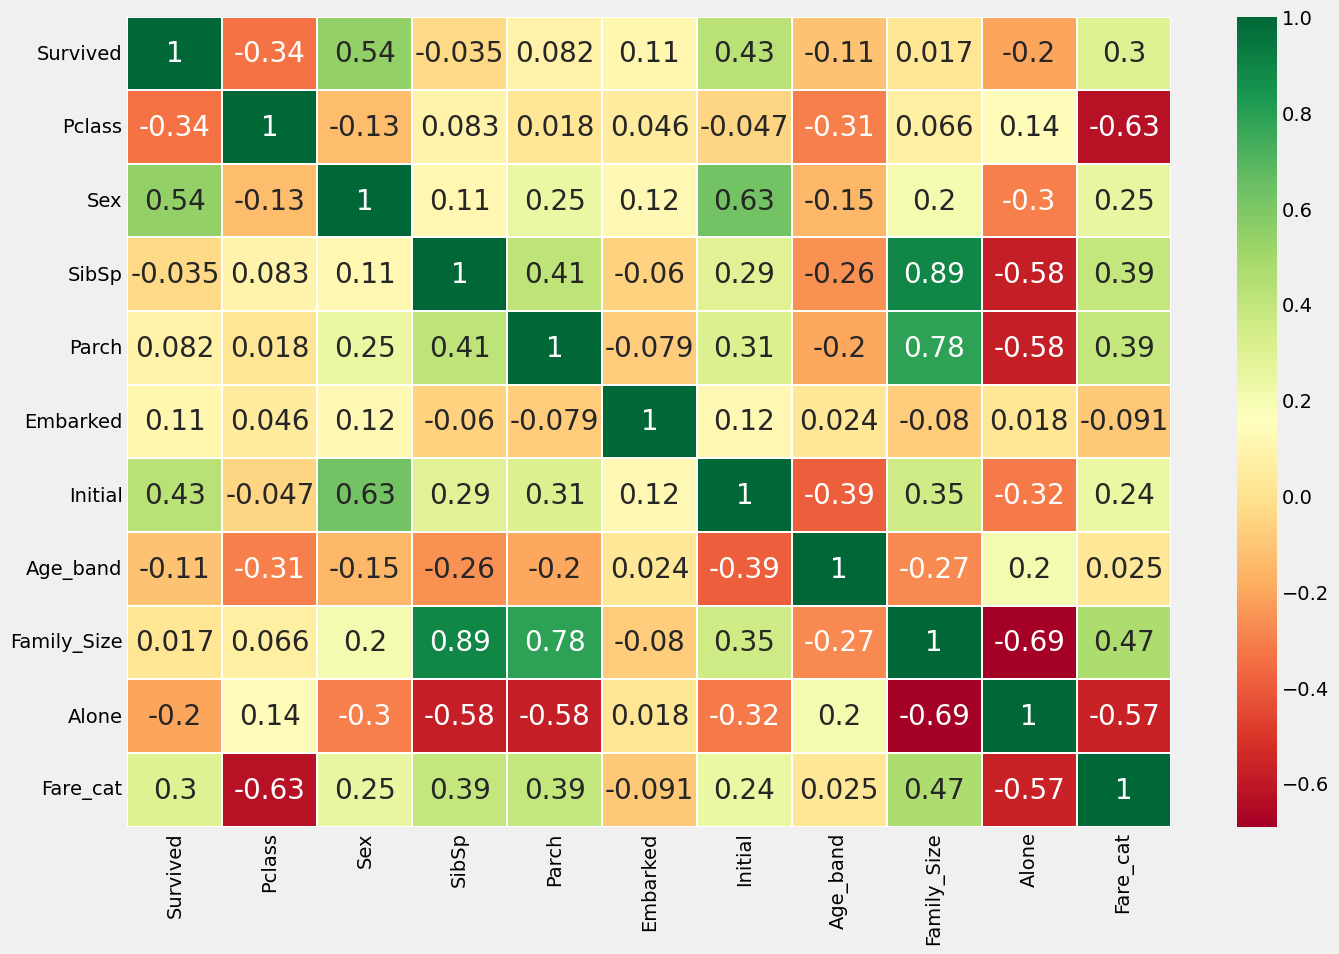

In [506]:
data.drop(columns=['Name','Age','Ticket','Fare','Cabin','Fare_Range','PassengerId'], inplace=True)

sns.heatmap(data.corr(),annot=True,cmap='RdYlGn',linewidths=0.2,annot_kws={'size':20})
# gcf означает get current figure — “получить текущую фигуру”.
fig=plt.gcf()
fig.set_size_inches(15,10)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

> ### Observations:
### Now the above correlation plot, we can see **some positively related features.** Some of them being **SibSp and Family_Size** and **Parch and Family_Size** and some negative ones like **Alone and Family_Size**.